# Explore here

In [13]:
# Your code here

import pandas as pd

df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv')
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Las columnas que nos interesan, según las consignas del proyecto, son: Latitude, Longitude y MedInc (ingreso medio) que vamos a hacer una agrupación con esta información.

In [14]:
df2 = df[['Latitude', 'Longitude', 'MedInc']]
df2.head()

,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462


In [15]:
# Luego nos piden que lo separemos en Trian y Test:

from sklearn.model_selection import train_test_split

x_train, x_test= train_test_split(df2, test_size=0.2, random_state=42)

x_train.head()

,Latitude,Longitude,MedInc
14196,32.71,-117.03,3.2596
8267,33.77,-118.16,3.8125
17445,34.66,-120.48,4.1563
14265,32.69,-117.11,1.9425
2271,36.78,-119.80,3.5542


In [16]:
# Ahora voy a entrenar mi modelo:

from sklearn.cluster import KMeans

model = KMeans(n_clusters=6, random_state=42)

model.fit(x_train)

x_train['cluster'] = model.predict(x_train)
x_train.head()

,Latitude,Longitude,MedInc,cluster
14196,32.71,-117.03,3.2596,3
8267,33.77,-118.16,3.8125,1
17445,34.66,-120.48,4.1563,1
14265,32.69,-117.11,1.9425,3
2271,36.78,-119.80,3.5542,5


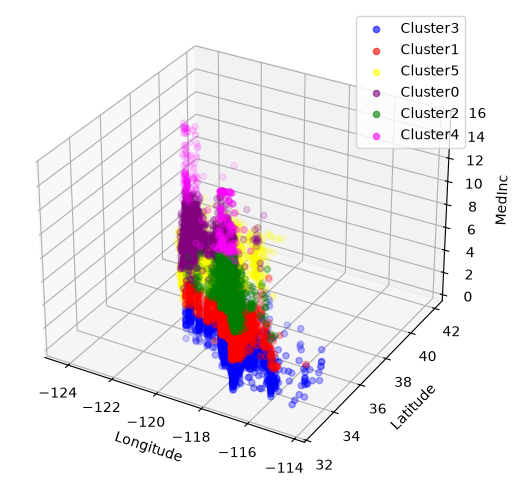

In [17]:
# Dibujemos esto para que lo podamos ver, lo vamos a graficar en 3D:

import matplotlib.pyplot as plt
from  mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

colores = ['blue', 'red', 'yellow', 'purple', 'green', 'magenta']

for i, color in zip(x_train['cluster'].unique(),colores):
    subset = x_train[x_train['cluster']==i]
    ax.scatter(subset['Longitude'], subset['Latitude'], subset['MedInc'], marker= 'o', c=[color], label=f'Cluster{i}', alpha= 0.6)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('MedInc')

ax.legend()
plt.show()


Aquí ya podemos ver cómo se dividieron los clusters.

In [18]:
pip install plotly

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
!pip install nbformat

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [20]:
import plotly.express as px

figg = px.scatter_3d (
    x_train,
    x = 'Longitude',
    y = 'Latitude',
    z= 'MedInc',
    color = 'cluster',
    color_discrete_sequence= ['blue', 'red', 'yellow', 'purple', 'green', 'magenta'],
    opacity= 0.6,
    labels= {
    'Longitude' : 'Longitud',
    'Latitude' :'Latitud',
    'MedInc' : 'Ingreso Medio',
    'cluster' : 'Clusters'

    }
)

figg.show()


In [21]:
# Ahora vamos a repetir los gráficos pero agregando las predicciones sobre test, con marcadores X, y para hacer eso  y para eso tenemos que hacer las predicciones, que es sencillo:

x_test['cluster'] = model.predict(x_test)

In [32]:

import plotly.graph_objects as go

color_map = {str(cluster): colores[i % len(colores)] for i, cluster in enumerate (x_train['cluster'].unique())}

figg = px.scatter_3d (
    x_train,
    x = 'Longitude',
    y = 'Latitude',
    z= 'MedInc',
    color = x_train['cluster'].astype(str),
    color_discrete_map = color_map,
    opacity= 0.6,
    labels= {
    'Longitude' : 'Longitud',
    'Latitude' :'Latitud',
    'MedInc' : 'Ingreso Medio',
    'cluster' : 'Clusters'

    }
)

for cluster_id in x_test['cluster'].unique():
    subset_test = x_test[x_test['cluster']==cluster_id]

    figg.add_trace(
        go.Scatter3d(
            x = subset_test['Longitude'],
            y = subset_test['Latitude'],
            z = subset_test['MedInc'],
            mode = 'markers',
            marker = dict(
                size = 4,
                symbol = 'x',
                color = color_map[str(cluster_id)],
                opacity= 0.8
            ),
            name = f'test {cluster_id}'
        
        )
    )


figg.show()

In [33]:
# Hacer un modelo que pueda predecir clusteres, y para eso debo dejar cluster como etiqueta:

y_train = x_train['cluster']
y_test = x_test['cluster']
x_train.drop('cluster', axis=1, inplace= True)
x_test.drop('cluster', axis=1, inplace= True)


In [35]:
from xgboost import XGBClassifier

model_xgb = XGBClassifier(random_state= 42)

model_xgb.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

In [36]:
# Predicciones: 

y_pred = model_xgb.predict(x_test)

from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)


0.9939437984496124

Y nos da un 99.39 % de precisión.

In [38]:
# Vamos a guardar los modelos:

from pickle import dump
dump(model, open ('../models/k_means_6_42.model', 'wb'))

model_xgb.save_model('../models/gxbc_default_42.json')
